# 1. Аудит многоканального ряда синхронизации

**Цели:** проверить схему, пропуски и масштаб каждого канала перед любым анализом. Данные фиксированы; истинной разметки момента синхронизации нет.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data/generated/kuramoto_synchronized_series.csv").exists())
DATA = ROOT / "data/generated/kuramoto_synchronized_series.csv"
SEED = 42
rng = np.random.default_rng(SEED)
df = pd.read_csv(DATA)
channel_names = [column for column in df.columns if column.startswith("channel_")]
x = df[channel_names].to_numpy()
assert np.isfinite(x).all() and x.ndim == 2

summary = df[channel_names].describe(percentiles=[.01, .05, .5, .95, .99]).T
summary

,count,mean,std,min,1%,5%,50%,95%,99%,max
channel_00,1500.0,-0.024616,0.700963,-0.999999,-0.999498,-0.987996,-0.044856,0.982222,0.999236,0.999998
channel_01,1500.0,-0.007328,0.700671,-1.000000,-0.999499,-0.987580,-0.011734,0.985082,0.999398,1.000000
channel_02,1500.0,-0.037834,0.693436,-0.999997,-0.999543,-0.988310,-0.065406,0.981070,0.999189,1.000000
channel_03,1500.0,-0.013149,0.704954,-1.000000,-0.999508,-0.988040,-0.024287,0.986869,0.999407,0.999997
channel_04,1500.0,-0.089879,0.706932,-0.999999,-0.999490,-0.988683,-0.187821,0.981104,0.999226,0.999998
channel_05,1500.0,-0.060472,0.687482,-1.000000,-0.999507,-0.988450,-0.124045,0.981336,0.999183,1.000000
channel_06,1500.0,-0.022181,0.701277,-1.000000,-0.999459,-0.988101,-0.040320,0.983807,0.999188,1.000000
channel_07,1500.0,-0.025049,0.698826,-0.999999,-0.999487,-0.988208,-0.043578,0.981098,0.999180,1.000000
channel_08,1500.0,-0.097079,0.711593,-0.999999,-0.999527,-0.988617,-0.191885,0.981274,0.999268,0.999996
channel_09,1500.0,-0.008069,0.699607,-1.000000,-0.999516,-0.987532,-0.009196,0.985085,0.999309,0.999997


,count,mean,std,min,1%,5%,50%,95%,99%,max
channel_00,1500.0,-0.024616,0.700963,-0.999999,-0.999498,-0.987996,-0.044856,0.982222,0.999236,0.999998
channel_01,1500.0,-0.007328,0.700671,-1.000000,-0.999499,-0.987580,-0.011734,0.985082,0.999398,1.000000
channel_02,1500.0,-0.037834,0.693436,-0.999997,-0.999543,-0.988310,-0.065406,0.981070,0.999189,1.000000
channel_03,1500.0,-0.013149,0.704954,-1.000000,-0.999508,-0.988040,-0.024287,0.986869,0.999407,0.999997
channel_04,1500.0,-0.089879,0.706932,-0.999999,-0.999490,-0.988683,-0.187821,0.981104,0.999226,0.999998
channel_05,1500.0,-0.060472,0.687482,-1.000000,-0.999507,-0.988450,-0.124045,0.981336,0.999183,1.000000
channel_06,1500.0,-0.022181,0.701277,-1.000000,-0.999459,-0.988101,-0.040320,0.983807,0.999188,1.000000
channel_07,1500.0,-0.025049,0.698826,-0.999999,-0.999487,-0.988208,-0.043578,0.981098,0.999180,1.000000
channel_08,1500.0,-0.097079,0.711593,-0.999999,-0.999527,-0.988617,-0.191885,0.981274,0.999268,0.999996
channel_09,1500.0,-0.008069,0.699607,-1.000000,-0.999516,-0.987532,-0.009196,0.985085,0.999309,0.999997


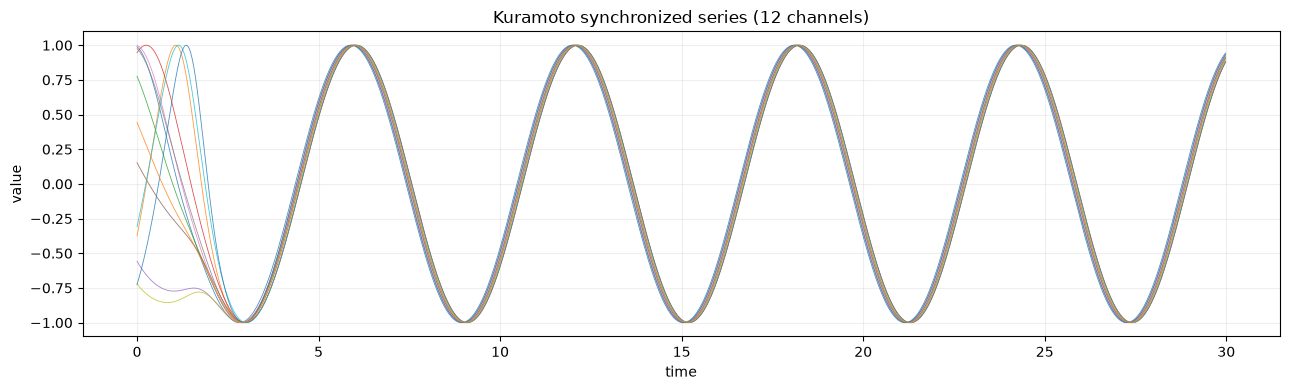

In [2]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df["timestamp"], x, lw=.6, alpha=.8)
ax.set(title=f"Kuramoto synchronized series ({len(channel_names)} channels)", xlabel="time", ylabel="value")
ax.grid(alpha=.2); fig.tight_layout()
summary

Каналы визуально сближаются к концу ряда — это кандидат на синхронизацию, а не доказанный факт.

**Самопроверка:** почему единая шкала осей не гарантирует сравнимость каналов? Что теряется при усреднении по каналам? Почему рост визуального сходства сам по себе не означает причинной связи между каналами?